In [4]:
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
from pathlib import Path
import sys

from utils import scrollview
from pedsilicoICH.ground_truth_definition.phantoms import *
from pedsilicoICH.image_reconstruction import *

df_volume = pd.read_csv('../src/pedsilicoICH/distributions/BHSD_volume_distributions.csv')
df_HU = pd.read_csv('../src/pedsilicoICH/distributions/BHSD_HU_distributions.csv')

mida_path = Path('/home/jayse.weaver/the_lab/MIDA_v1.0/MIDA_v1_voxels')
NIHPD_path = Path('/home/jayse.weaver/PedSilicoICH/NIHPD_Head_Phantom/')
#phantom = MIDA_Head(mida_path)

# TEST PERFORMANCE
volumes = np.linspace(1, 80, 80)
#volumes = [60]
new_volumes = []

for i in range(len(volumes)):
    print('fitting volume #'+str(i)+', value: '+str(volumes[i]))
    #phantom = MIDA_Head(mida_path)
    phantom = NIHPD_Head(NIHPD_path, age=11.5)

    dx = phantom.dx
    dy = phantom.dy
    dz = phantom.dz

    # optional, add lesion (comment out if just testing recon)
    phantom.insert_lesion(lesion_type='subdural', volume=volumes[i], intensity=100,
                        init_slice=None, mass_effect=False, seed=None)

    hemorrhage_volume = (len(np.argwhere(phantom._lesion[0] != 0)))*((dx*dy*dz)/1000)
    print('new volume: ' + str(hemorrhage_volume))
    new_volumes.append(hemorrhage_volume)

dfsyn = pd.DataFrame()
dfsyn['defined'] = volumes
dfsyn['new'] = new_volumes

scrollview(phantom._phantom)

nib.save(nib.Nifti1Image(phantom._phantom, np.eye(4)), 'test.nii')

scrollview(phantom._lesion[0])


fitting volume #0, value: 1.0
new volume: 1.247
fitting volume #1, value: 2.0
new volume: 2.312
fitting volume #2, value: 3.0
new volume: 2.95
fitting volume #3, value: 4.0
new volume: 5.455
fitting volume #4, value: 5.0
new volume: 4.9350000000000005
fitting volume #5, value: 6.0
new volume: 5.388
fitting volume #6, value: 7.0
new volume: 8.203
fitting volume #7, value: 8.0
new volume: 5.297
fitting volume #8, value: 9.0
new volume: 7.066
fitting volume #9, value: 10.0
new volume: 13.377
fitting volume #10, value: 11.0
new volume: 8.753
fitting volume #11, value: 12.0
new volume: 18.138
fitting volume #12, value: 13.0
new volume: 10.894
fitting volume #13, value: 14.0
new volume: 20.69
fitting volume #14, value: 15.0
new volume: 12.207
fitting volume #15, value: 16.0
new volume: 11.368
fitting volume #16, value: 17.0
new volume: 15.578000000000001
fitting volume #17, value: 18.0
new volume: 13.157
fitting volume #18, value: 19.0
new volume: 19.208000000000002
fitting volume #19, value

interactive(children=(IntSlider(value=94, description='idx', max=188), Output()), _dom_classes=('widget-intera…

interactive(children=(IntSlider(value=94, description='idx', max=188), Output()), _dom_classes=('widget-intera…

Text(0, 0.5, 'Output Volume')

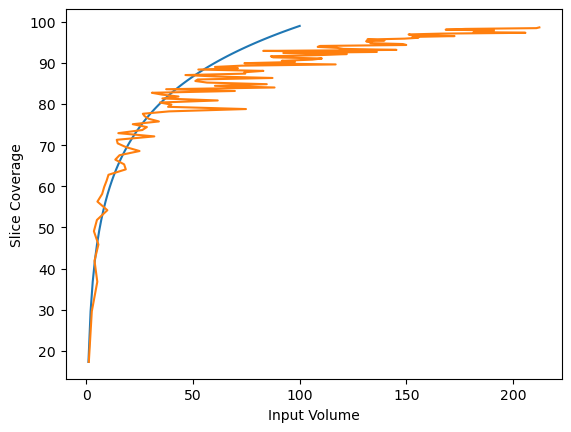

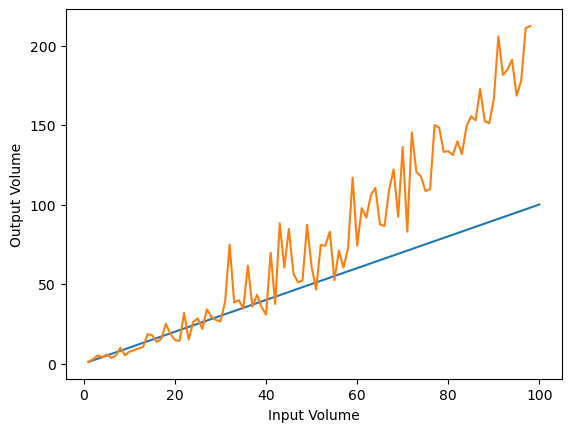

In [3]:
# temp
import math

slice_coverage = []
for i in range(len(volumes)):
    #slice_coverage.append(13.942*math.log(volumes[i]) + 13.449)
    slice_coverage.append(17.739*math.log(volumes[i]) + 17.314)

plt.figure()
plt.plot(volumes, slice_coverage)
plt.xlabel('Input Volume')
plt.ylabel('Slice Coverage')
plt.plot(new_volumes, slice_coverage[:len(new_volumes)])

plt.figure()
plt.plot(volumes, volumes)
plt.plot(volumes[:len(new_volumes)], new_volumes)
plt.xlabel('Input Volume')
plt.ylabel('Output Volume')

In [2]:
from pedsilicoICH.image_acquisition import Scanner

phantom.patient_name = 'test_70kv_mono'
scanner = Scanner(phantom)
scanner

<class 'numpy.ndarray'>
(189, 233, 197)


KeyboardInterrupt: 

In [ ]:
scanner.scout_view(startZ=10, endZ=18, table_speed=0)

In [ ]:
scanner.run_scan(mA=280, kVp=70, startZ=10, endZ=18, views=1000)

In [ ]:
scanner.run_recon(sliceThickness=5, kernel='standard')

In [ ]:
scanner.write_to_dicom("TEST_NIHPD_70kv_mono_standard1000.dcm")

scrollview(scanner.recon)